In [41]:
import pandas as pd
import glob
import duckdb
import tqdm
from pathlib import Path
import numpy as np
import os
from trebl_tools import pipelines, finder, umi_deduplicate, initial_map, map_refiner
import seaborn as sns
import matplotlib.pyplot as plt

# exploring original tables

In [2]:
con = duckdb.connect("../../duckdb/GCN4_final.db", read_only=True)

In [3]:
tables_df = con.execute("SHOW TABLES").fetchdf()
tables_df[tables_df["name"].str.contains("trebl_experiment_yeast_pool_C_umi_AD_1_0_AD_AD_BC_initial")].iloc[0].iloc[0]

'trebl_experiment_yeast_pool_C_umi_AD_1_0_AD_AD_BC_initial'

In [24]:
con.execute("""
SELECT COUNT(DISTINCT umi) AS unique_umis
FROM trebl_experiment_yeast_pool_C_umi_AD_1_0_AD_AD_BC_initial
WHERE AD_BC = 'CTGTTGTGAAA'
  AND AD_qual = 1
  AND AD_BC_qual = 1
  AND Designed = 1
  AND UMI_qual = 1
""").fetchdf()

,unique_umis
0,1


In [23]:
con.execute("""
SELECT *
FROM trebl_experiment_yeast_pool_C_umi_AD_1_0_AD_AD_BC_initial
WHERE AD_BC = 'CTGTTGTGAAA'
  AND AD_qual = 1
  AND AD_BC_qual = 1
  AND Designed = 1
  AND UMI_qual = 1
LIMIT 5
""").fetchdf()

,AD,AD_qual,AD_BC,AD_BC_qual,UMI,UMI_qual,Designed
0,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,GGCTGGTCAAGA,True,1
1,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,GGCTGGTCAAGA,True,1
2,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,GGCTGGTCAAGA,True,1
3,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,GGCTGGTCAAGA,True,1
4,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,GGCTGGTCAAGA,True,1


In [25]:
con.execute("""
SELECT COUNT(DISTINCT umi) AS unique_umis
FROM trebl_experiment_yeast_pool_C_umi_AD_1_0_AD_AD_BC_initial
WHERE AD_BC = 'ACCCATCCAGA'
  AND AD_qual = 1
  AND AD_BC_qual = 1
  AND Designed = 1
  AND UMI_qual = 1
""").fetchdf()

,unique_umis
0,1


# making fixed table

In [2]:
yeast_pool_C_umi_AD_seq_files = glob.glob("/global/scratch/projects/fc_mvslab/data/sequencing/20250218_MZCCSCU_MedGenome/MZ/results/assembled/*1_0*")
# yeast_pool_C_umi_output_path = "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi" 

In [9]:
EC_AD = finder.Barcode(name = "AD",
                        preceder = "GGCTAGC",
                       post = "",
                       length = 120)

EC_AD_BC = finder.Barcode(name = "AD_BC",
                       preceder = "CGCGCC",
                       post = "",
                       length = 11)

EC_RPTR_BC = finder.Barcode(name = "RPTR_BC",
                       preceder = "CTCGAG",
                       post = "",
                       length = 14)
AD_objects = [EC_AD, EC_AD_BC]


AD_UMI = finder.Barcode(name = "UMI",
                        preceder = "TGATTT",
                       post = "",
                       length = 12)

AD_UMI_objects = [EC_AD, EC_AD_BC, AD_UMI]

In [14]:
db_path = "../../duckdb/GCN4_umi_discrepancy_umi_flank_fixed_full.db"

In [15]:
for file_path in yeast_pool_C_umi_AD_seq_files:
    
    # Get the file naeme to use for database
    base_name = os.path.basename(file_path)
    name_only = base_name.split('.')[0]
    print(name_only) 

    # # Get the file naeme to use for output
    # umi_path = os.path.join(yeast_pool_C_umi_output_path, f"trebl_experiment_yeast_pool_C_umi_{name_only}")
    # print(umi_path)

    # Extract UMIs and barcodes from reads
    umi_mapper = initial_map.InitialMapper(db_path = db_path,
                                       step_name = f"trebl_experiment_yeast_pool_C_umi_{name_only}", 
                                       seq_file = file_path,
                                       design_file_path = "/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/A10_sequencing/v2/current/a10_designfile.csv",
                                       bc_objects = AD_objects,
                                        umi_object=AD_UMI,
                                       reverse_complement = True)
    umi_mapper.create_map()
    
    # Only keep barcodes of correct length
    # refiner = map_refiner.MapRefiner(db_path = db_path,
    #                                     bc_objects=AD_objects,
    #                                     column_pairs = [],
    #                                     map_order = ['quality', 'designed'],
    #                                     step_name=f"trebl_experiment_yeast_pool_C_umi_{name_only}", 
    #                                     descriptor = "",
    #                                     output_figures_path='/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/figures',
    #                                     reads_threshold = 0,
    #                                     umi_object = AD_UMI)
    # refiner.refine_map_from_db()
    # refiner.plot_loss()

    # # Run both deduplications
    # deduplicator = umi_deduplicate.UMIDeduplicator(db_path = db_path,
    #                                                     bc_objects = AD_objects,
    #                                                     step_name = f"trebl_experiment_yeast_pool_C_umi_{name_only}", 
    #                                                     descriptor = "",
    #                                                     step1_map_name = None,
    #                                                     fastq_path = file_path,
    #                                                     output_path = umi_path, 
    #                                                    refined_map_suffix = 'designed')

    # deduplicator.run_simple_deduplication()
    # deduplicator.save_simple_deduplication()
    

AD_1_0
Reading 1 FASTQ/TXT file(s)...
Done in 5.34 minutes.

Reverse complement of sequences...
Done in 1.39 minutes.

Extracting 2 barcodes...
False
GGCTAGC

AD: extracting 120 bases after preceder 'GGCTAGC'
False
CGCGCC

AD_BC: extracting 11 bases after preceder 'CGCGCC'
Done in 52.79 seconds.

Extracting UMI...
True
TGATTT

UMI: extracting 12bp UMI after flank 'TGATTT' near end of read
Done in 9.02 seconds.

Merging with design file...
Done in 31.81 seconds.

Mapping complete.


In [27]:
con = duckdb.connect("../../duckdb/GCN4_umi_discrepancy_umi_flank_fixed_full.db")

In [28]:
con.execute("""
SELECT * 
FROM trebl_experiment_yeast_pool_C_umi_AD_1_0_AD_AD_BC_initial
LIMIT 10
""").fetchdf()

,AD,AD_qual,AD_BC,AD_BC_qual,UMI,UMI_qual,Designed
0,AAACCATTGCCACCAATTATTGTTGAAGATCCATCTGATACTACTG...,True,TGTAAGATTGC,True,GTAATGTATAAC,True,1
1,TTGACTAATAGATTTACTCCAGCTCAATCTCCACATCAATTCTATG...,True,TAAATCTTTTA,True,CGTAACCATAAA,True,1
2,GGTCCAACTATTTCTCCAAGAGAATTGTTGATGAATCCACCAACTT...,True,GATTAGTTGGC,True,CCCTTGCTCTAG,True,1
3,ACTTCTGATGTTAATTGTGCTGAAGCTGAATTGCAAAGAGAACATG...,True,ACTAGTCTGGA,True,TCGCCCTATTGA,True,1
4,AGATCTCCATTGCCAGTTACTAGGATTCCATTGCCAGCTAATCAAC...,True,GTGCCTATTGC,True,ATGCCCGTTAGA,True,1
5,ACTGCATTTGAAGGTGGTGCTAATACTGCATTCTCTTCTCCAGCTG...,True,CAGGCAACGCG,True,GGCAACGATGGC,True,1
6,TTTCATACTCCAAGACATATTGCTGCTTATCAAAGAGCTTTGATTC...,True,AGTAAGCCAAG,True,AAACCACCACAT,True,1
7,TTGGATCAAGCTTTGTCTGGTGATCCATGGTATCCATTGTTTCCAC...,True,TGTTTATTGTA,True,TAAAACACATCA,True,1
8,GGTTCTCATAATATTGGTACTGTTTCTCCACAAGATTTGTTGATTC...,True,CCCAATAGCTT,True,CTAATATCTGAC,True,1
9,AATTTGACTTCTCCAGATATTGATGCTTCTCCATTTATTAATGATT...,True,GGGCGCAGTTC,True,GGCTCCGATATC,True,1


In [29]:
row_count = con.execute("""
    SELECT COUNT(*) AS total_rows
    FROM trebl_experiment_yeast_pool_C_umi_AD_1_0_AD_AD_BC_initial
""").fetchdf()

print(row_count)

   total_rows
0   120435636


In [30]:
con.execute("""
SELECT *
FROM trebl_experiment_yeast_pool_C_umi_AD_1_0_AD_AD_BC_initial
WHERE AD_BC = 'CTGTTGTGAAA'
  AND AD_qual = 1
  AND AD_BC_qual = 1
  AND Designed = 1
  AND UMI_qual = 1
LIMIT 20
""").fetchdf()

,AD,AD_qual,AD_BC,AD_BC_qual,UMI,UMI_qual,Designed
0,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,CATGTCGCCTTG,True,1
1,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,ATCAGTAATTGA,True,1
2,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,TAAGCGCTCTAT,True,1
3,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,CCCAGAGTACCA,True,1
4,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,CCCAGAGTACCA,True,1
5,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,ATATATATTATA,True,1
6,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,AAGCCTATAAGG,True,1
7,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,AAGCCTATAAGG,True,1
8,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,AAGCCTATAAGG,True,1
9,GTTGCTGAATCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATG...,True,CTGTTGTGAAA,True,CAAGCTCGGCCC,True,1


In [33]:
distinct_umi_count = con.execute("""
    SELECT COUNT(DISTINCT UMI) AS n_distinct_umis
    FROM trebl_experiment_yeast_pool_C_umi_AD_1_0_AD_AD_BC_initial
    WHERE AD_BC = 'CTGTTGTGAAA'
      AND AD_qual = 1
      AND AD_BC_qual = 1
      AND Designed = 1
      AND UMI_qual = 1
""").fetchdf()

print(distinct_umi_count)

# Yay! This matches the expectation!

   n_distinct_umis
0              485


In [35]:
umi_counts = con.execute("""
SELECT
    AD,
    AD_BC,
    COUNT(DISTINCT UMI) AS distinct_umi_count
FROM trebl_experiment_yeast_pool_C_umi_AD_1_0_AD_AD_BC_initial
GROUP BY AD, AD_BC
ORDER BY distinct_umi_count DESC;""").fetchdf()
umi_counts

,AD,AD_BC,distinct_umi_count
0,,ACTTCTAAATA,195128
1,,ACTTCTAAATC,44263
2,CCATCTGACTTTCCATTTCCAGAAACTTTGACTTCTTCTACTGCTT...,TTATTCGAATT,14967
3,,,10735
4,TCTTCTTCATTTGGTTTGTCTGGTAATTCTTCTCAACATAGATTGT...,CGCGGCTACAA,9374
...,...,...,...
2772021,ATCTTGCCAAGAGACTTCTCCGTCTTTACTACTGATTCTCAATCTT...,AAGCAAAAATC,1
2772022,CCAGTTGCTTTGAAGAGAGCTAGAAATACTGAAGCTGCTAGAAGAT...,TTACAACAGTT,1
2772023,AGAAGAGTTTGGACTTTGGAAATGGTTAGATCTTTGAATATGACTT...,TGAAACACTCT,1
2772024,TCTTCTCCAGCTGTTCCAACTGTCTTTGACTTTAATTCTGCTTCTT...,AGACTTGACGA,1


In [60]:
activity_comparison = pd.read_csv("../../output/GCN4_sk_vs_ec_activities.csv")
activity_comparison

,Unnamed: 0,AD,AD_BC,RPTR_BC,rep,time,EC_AD_umi_count,EC_RT_umi_count,EC_activity,AD_umi_count,RT_umi_count,SK_activity
0,0,GGTACTATTTCTCCTAAAGATTTGATGATGGATGCTTCTGTTCCAC...,ACTCGGAATTG,TATACATCCACCAT,3,5,646,402,0.622291,1,403,403.000000
1,1,GATGCTTCTCCATTCTTGAATGAATCATTTGAAACTTCTCCAATGT...,CATCTAGGAAA,AAGTGGTGAGAAGC,3,5,806,2784,3.454094,806,2779,3.447891
2,2,TCATTTGAAACTTCTCCAATGTTTCAAGGTGAACCAATGTTAAATT...,TGGGAGCCCTT,GTACGAAGTCAGTG,3,5,657,1349,2.053272,660,1362,2.063636
3,3,TTGGATTTGGATGACTTTACTGGATTTGAAGGTGGTGCTTCTACTA...,TCTTAGGCTCG,AAAGTTCTCAGACA,3,5,917,690,0.752454,920,679,0.738043
4,4,CAAAGACCAACTAGACCACAAGTTCCATTGTTCTCTCAATCTACTG...,GCCCTTGTATT,TTAGTATTTTATCT,3,5,533,140,0.262664,534,139,0.260300
...,...,...,...,...,...,...,...,...,...,...,...,...
296868,296868,ACTTCTGCTTCTTCTGCTTCTCAAATTGTTGTTCATCCAGGTGGTG...,GCCCCCCGTTG,TATGTAATTAACCT,1,240,9,12,1.333333,9,12,1.333333
296869,296869,AATTTGTGGATGGGTTTGCATGGTCCTAAAGATCAAGAAGCTAGAG...,CGGGGTGTCTG,TTCAGAGAAAGCGC,1,240,57,13,0.228070,56,13,0.232143
296870,296870,AGACATTCTTCTAATATTCCATCTGCTTCTTCTTTGCAGAATCAAA...,GAAAACTTTAA,AAATCAGGTGCGCT,1,240,53,3,0.056604,53,3,0.056604
296871,296871,TCTTTGTCTTTGGGTAAAGGTTGTGCTGGTGAATTGACTCCACCAC...,GCATGAGTTAG,ATAAAACTAGCCTG,1,240,536,1,0.001866,536,670,1.250000


In [61]:
activity_comparison = pd.merge(activity_comparison, umi_counts, on = ["AD", "AD_BC"])
activity_comparison

,Unnamed: 0,AD,AD_BC,RPTR_BC,rep,time,EC_AD_umi_count,EC_RT_umi_count,EC_activity,AD_umi_count,RT_umi_count,SK_activity,distinct_umi_count
0,0,GGTACTATTTCTCCTAAAGATTTGATGATGGATGCTTCTGTTCCAC...,ACTCGGAATTG,TATACATCCACCAT,3,5,646,402,0.622291,1,403,403.000000,665
1,1,GATGCTTCTCCATTCTTGAATGAATCATTTGAAACTTCTCCAATGT...,CATCTAGGAAA,AAGTGGTGAGAAGC,3,5,806,2784,3.454094,806,2779,3.447891,769
2,2,TCATTTGAAACTTCTCCAATGTTTCAAGGTGAACCAATGTTAAATT...,TGGGAGCCCTT,GTACGAAGTCAGTG,3,5,657,1349,2.053272,660,1362,2.063636,644
3,3,TTGGATTTGGATGACTTTACTGGATTTGAAGGTGGTGCTTCTACTA...,TCTTAGGCTCG,AAAGTTCTCAGACA,3,5,917,690,0.752454,920,679,0.738043,806
4,4,CAAAGACCAACTAGACCACAAGTTCCATTGTTCTCTCAATCTACTG...,GCCCTTGTATT,TTAGTATTTTATCT,3,5,533,140,0.262664,534,139,0.260300,522
...,...,...,...,...,...,...,...,...,...,...,...,...,...
296435,296868,ACTTCTGCTTCTTCTGCTTCTCAAATTGTTGTTCATCCAGGTGGTG...,GCCCCCCGTTG,TATGTAATTAACCT,1,240,9,12,1.333333,9,12,1.333333,30
296436,296869,AATTTGTGGATGGGTTTGCATGGTCCTAAAGATCAAGAAGCTAGAG...,CGGGGTGTCTG,TTCAGAGAAAGCGC,1,240,57,13,0.228070,56,13,0.232143,44
296437,296870,AGACATTCTTCTAATATTCCATCTGCTTCTTCTTTGCAGAATCAAA...,GAAAACTTTAA,AAATCAGGTGCGCT,1,240,53,3,0.056604,53,3,0.056604,59
296438,296871,TCTTTGTCTTTGGGTAAAGGTTGTGCTGGTGAATTGACTCCACCAC...,GCATGAGTTAG,ATAAAACTAGCCTG,1,240,536,1,0.001866,536,670,1.250000,358


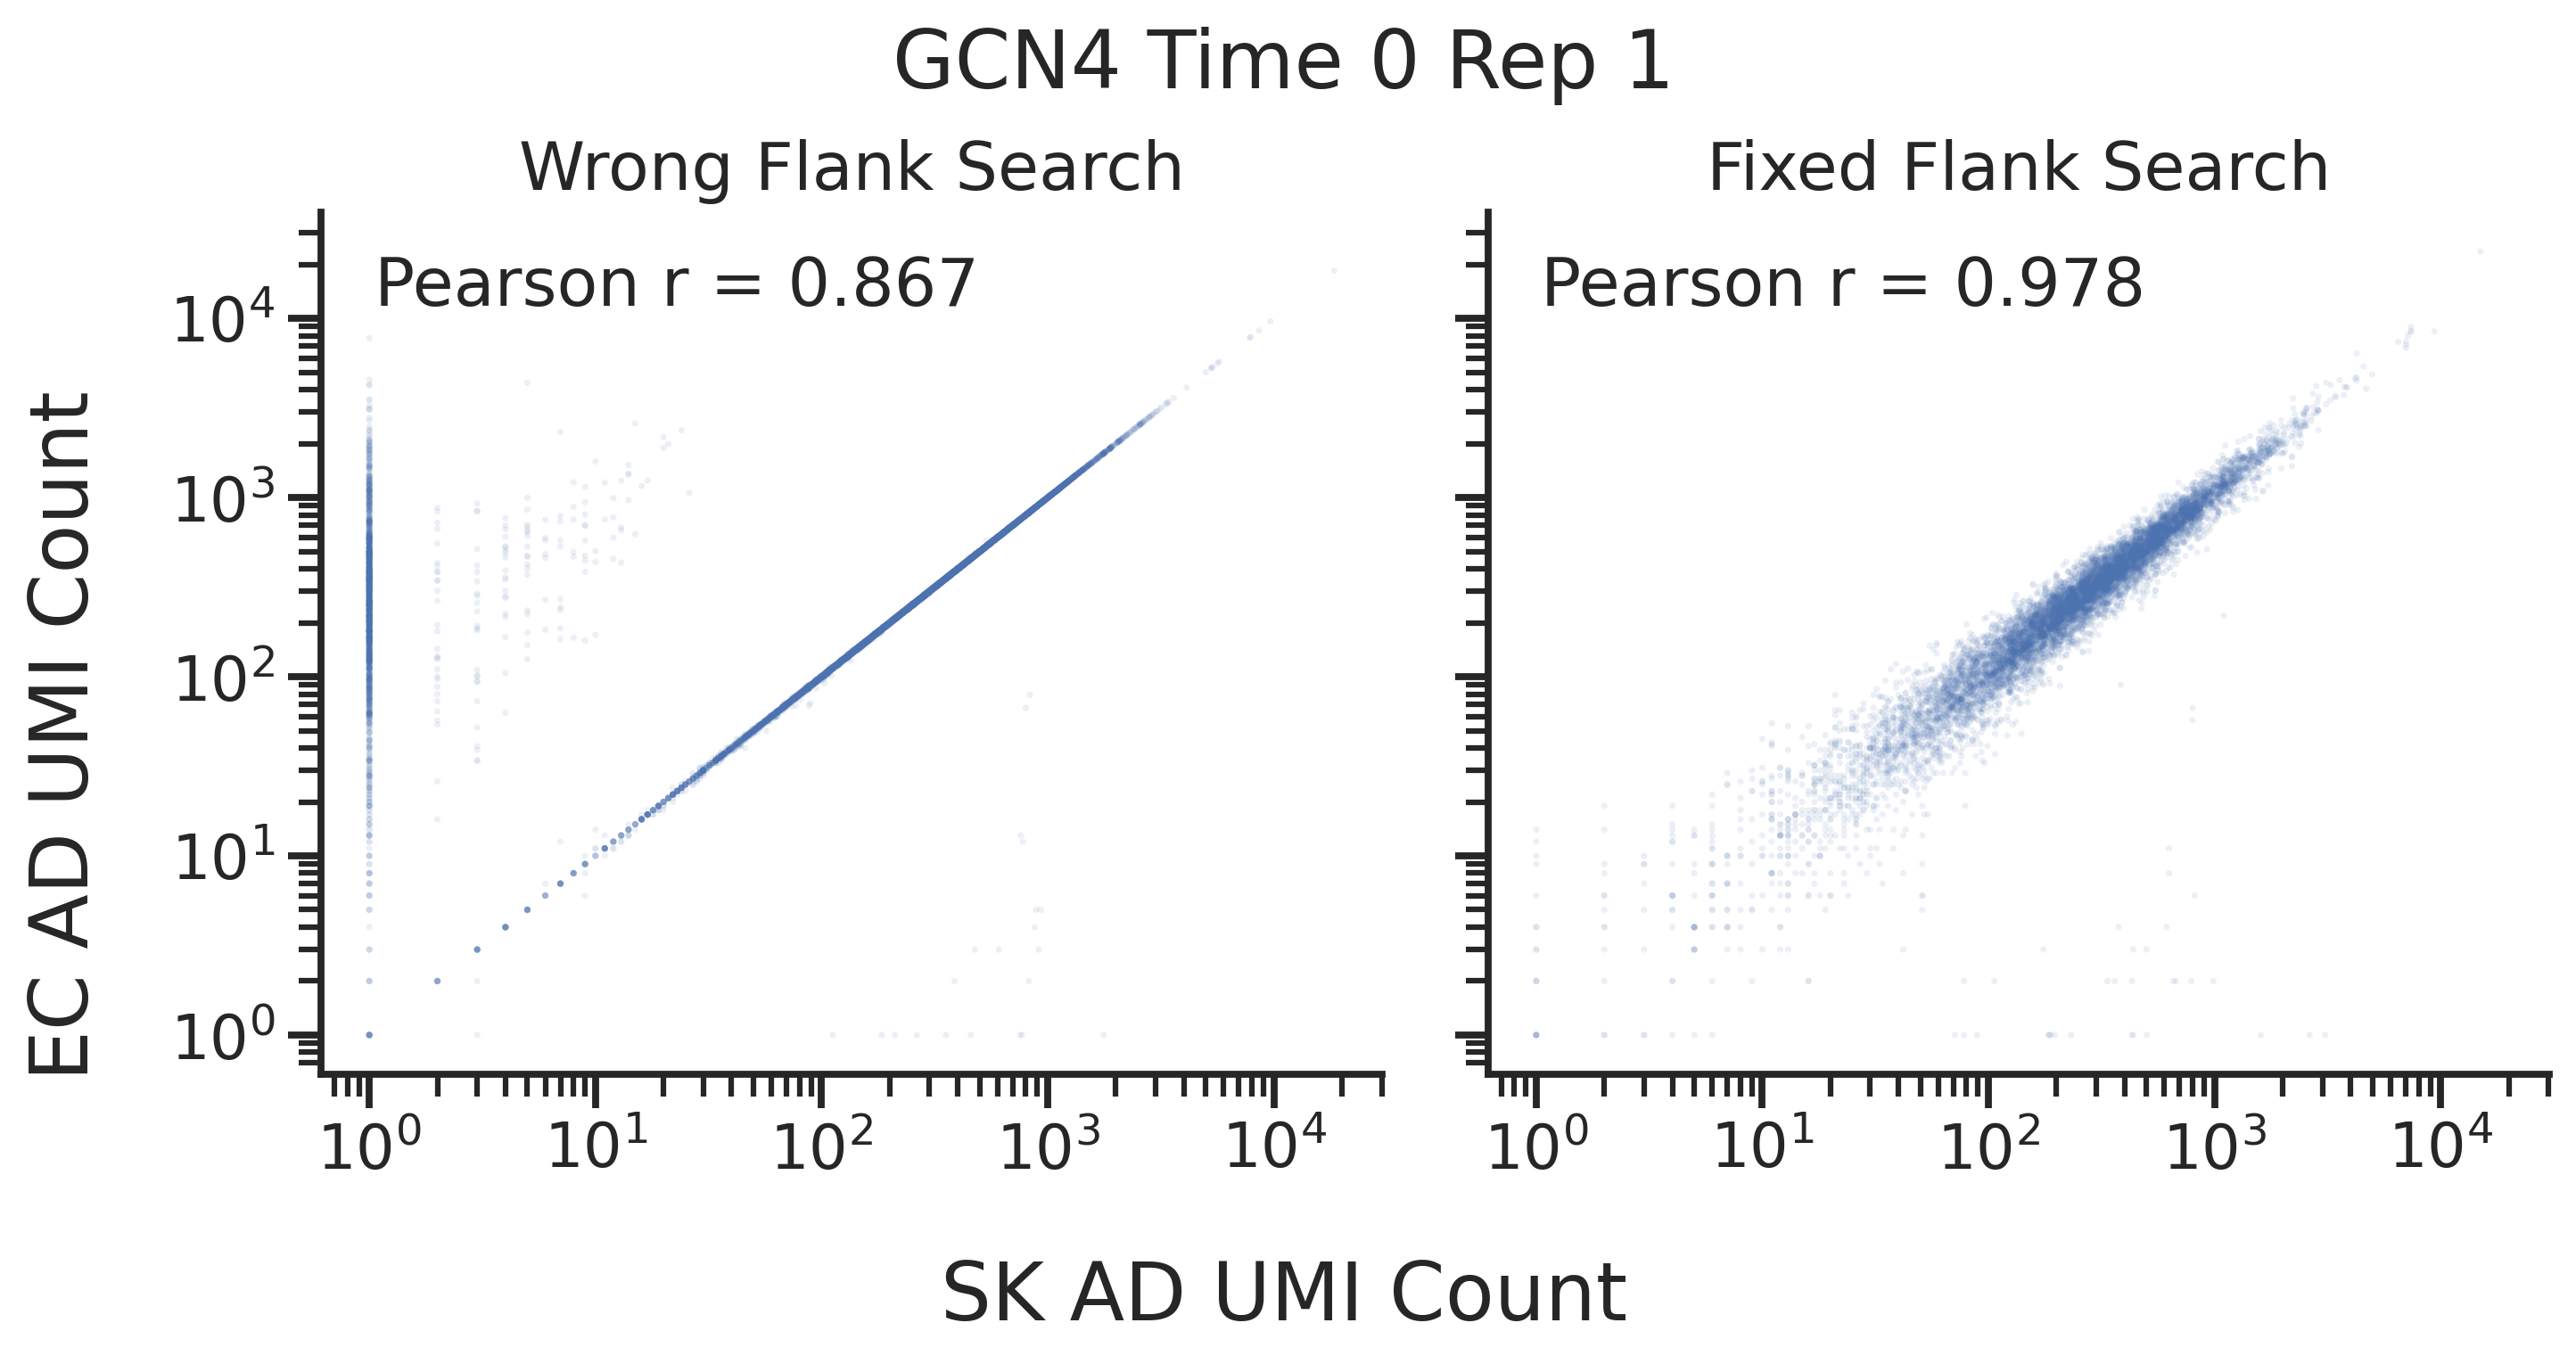

In [103]:
import numpy as np
from scipy.stats import pearsonr

sns.set_context('talk')
sns.set_style('ticks')
fig, axs = plt.subplots(1,2, figsize=(10,5), sharex=True, sharey=True, dpi = 300)

df1 = activity_comparison.sample(10000)
df2 = activity_comparison.sample(10000)

sns.scatterplot(
    data=df1,
    x="AD_umi_count",
    y="EC_AD_umi_count",
    ax=axs[0],
    alpha=0.1,
    s=3,
    edgecolor='none'
)

sns.scatterplot(
    data=df2,
    x="distinct_umi_count",
    y="EC_AD_umi_count",
    ax=axs[1],
    alpha=0.1,
    s=3,
    edgecolor='none'
)

axs[0].set_ylabel("")
axs[0].set_title("Wrong Flank Search")

#axs[1].set_ylabel("EC AD umi count")
axs[1].set_title("Fixed Flank Search")

fig.supxlabel("SK AD UMI Count", y = 0.05)
fig.supylabel("EC AD UMI Count", x = 0.03)

for ax, xcol in zip(axs, ["AD_umi_count", "distinct_umi_count"]):

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("")

    x = activity_comparison[xcol]
    y = activity_comparison["EC_AD_umi_count"]

    mask = (x > 0) & (y > 0)  # needed because log axes can't show 0
    r, _ = pearsonr(x[mask], y[mask])

    ax.text(
        0.05, 0.95,
        f"Pearson r = {r:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top"
    )

plt.tight_layout()
plt.suptitle("GCN4 Time 0 Rep 1", y = 1.03)
sns.despine()